In [1]:
import os
import json
import time

import cv2
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import torch
from vidgear.gears import WriteGear

from koger_detection.obj_det.mydatasets import VideoDataset
from koger_detection.obj_det.predictors import Predictor

/home/berdahl/miniforge3/envs/freshy/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
load_dotenv()

True

In [3]:
#video_name = "bear_big2a_2023_08_16_koger_01_01_DJI_20230816175814_0573_D"
#video_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), video_name, "media")
#video_file = os.path.join(video_folder, video_name + ".MP4")

#if os.path.exists(video_file):
#    print(f"video exists")

#video_name = "bear_big2a_2023_08_16_koger_01_05_DJI_20230816175814_0573_D"  # <-- fix id
#video_name = "bear_clipped" #trying a 10-second clip
video_name = "clipped_23_16"

project_root = os.environ["PROJECT_DROPBOX"]  # safer than get()
video_file = os.path.join(project_root, "media", f"{video_name}.mp4")      # <-- fix location

print("video_file:", video_file)
print("exists:", os.path.exists(video_file))

out_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), video_name)
os.makedirs(out_folder, exist_ok=True)

out_name = "test.mp4"


create_video = False

video_file: /home/berdahl/Dropbox/bear-hunting/media/clipped_23_16.mp4
exists: True


In [4]:
run_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), "models", "bear-hunting", "runs", "main")
run_name = "05-14-2025-15-45-22"
cfg_file = os.path.join(run_folder, run_name, "cfg.json") 

with open(cfg_file, "r") as f:
    cfg = json.load(f)
    
cfg_m = cfg['model']
cfg_m['model_weights_pth'] = os.path.join(run_folder, run_name, "final_model.pth")
cfg_m['box_detections_per_img'] = 512
cfg_m['rpn_pre_nms_top_n_test'] = 4000
cfg_m['rpn_post_nms_top_n_test'] = 2000

In [5]:
cfg_file

'/home/berdahl/Dropbox/bear-hunting/models/bear-hunting/runs/main/05-14-2025-15-45-22/cfg.json'

In [6]:

predictor = Predictor(cfg_m)

In [7]:
print("Video file:", video_file)
print("Exists:", os.path.exists(video_file))
print("Size (bytes):", os.path.getsize(video_file) if os.path.exists(video_file) else None)


Video file: /home/berdahl/Dropbox/bear-hunting/media/clipped_23_16.mp4
Exists: True
Size (bytes): 199996304


In [8]:
ls /home/berdahl/Dropbox/bear-hunting/media/

bear_big2a_2023_08_16_koger_01_05_DJI_20230816175814_0573_D.MP4
bear_clipped.mp4
clipped_23_16.mp4
clipped_23_32.mp4
clipped_23_8.mp4
clipped_25.mp4
confluence_main_2023_08_12_berdahl_01_3_DJI_0442.MP4*
confluence_main_2025_08_08_berdahl_01_1_DJI_0677.MP4*
fish_clipped.mp4


In [9]:
import torch.utils.data._utils.collate as coll
print("torch collate numpy seen as:", coll.np)

torch collate numpy seen as: <module 'numpy' from '/home/berdahl/miniforge3/envs/freshy/lib/python3.10/site-packages/numpy/__init__.py'>


In [10]:
import setuptools
print("setuptools:", setuptools.__version__)

setuptools: 59.6.0


In [11]:
import torch.utils.data._utils.collate as coll
import numpy as np

print("coll.np is None?", coll.np is None)
print("coll.np:", coll.np)
print("np.ndarray is:", np.ndarray)

coll.np is None? False
coll.np: <module 'numpy' from '/home/berdahl/miniforge3/envs/freshy/lib/python3.10/site-packages/numpy/__init__.py'>
np.ndarray is: <class 'numpy.ndarray'>


In [12]:
import torch.utils.data._utils.collate as coll
import numpy as np

print("np.ndarray in collate map?", np.ndarray in coll.default_collate_fn_map)
print("collate map keys (types):", list(coll.default_collate_fn_map.keys()))

np.ndarray in collate map? True
collate map keys (types): [<class 'torch.Tensor'>, <class 'numpy.ndarray'>, (<class 'numpy.bool_'>, <class 'numpy.number'>, <class 'numpy.object_'>), <class 'float'>, <class 'int'>, <class 'str'>, <class 'bytes'>]


In [13]:
ds = VideoDataset(video_file)
data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)

print("batch_size:", data_loader.batch_size)
print("_auto_collation:", data_loader._auto_collation)
print("batch_sampler type:", type(data_loader.batch_sampler))
print("sampler type:", type(data_loader.sampler))
print("dataset base classes:", [c.__name__ for c in type(ds).mro()[:6]])

batch_size: 1
_auto_collation: True
batch_sampler type: <class 'torch.utils.data.sampler.BatchSampler'>
sampler type: <class 'torch.utils.data.dataloader._InfiniteConstantSampler'>
dataset base classes: ['VideoDataset', 'IterableDataset', 'Dataset', 'Iterable', 'Generic', 'object']


In [14]:
import inspect
from koger_detection.obj_det.mydatasets import VideoDataset

print("VideoDataset file:", inspect.getsourcefile(VideoDataset))
print("VideoDataset MRO:", [c.__name__ for c in VideoDataset.mro()[:5]])

VideoDataset file: /home/berdahl/code/detection-projects/koger_detection/koger_detection/obj_det/mydatasets.py
VideoDataset MRO: ['VideoDataset', 'IterableDataset', 'Dataset', 'Iterable', 'Generic']


In [15]:
import torch
print(torch.__version__)

2.3.1+cu121


In [16]:
import torch, torchvision
print("torch", torch.__version__)
print("torchvision", torchvision.__version__)

torch 2.3.1+cu121
torchvision 0.18.1+cu121


In [17]:
################################################

In [18]:
ds = VideoDataset(video_file)

for f in ds:
    print(f)
    break

[[[129 168  35]
  [123 162  29]
  [112 151  20]
  ...
  [103 144  58]
  [108 149  63]
  [109 150  64]]

 [[126 165  32]
  [126 165  32]
  [126 165  34]
  ...
  [109 150  64]
  [105 146  60]
  [101 142  56]]

 [[160 199  68]
  [160 199  68]
  [160 198  72]
  ...
  [112 153  67]
  [119 160  74]
  [112 153  67]]

 ...

 [[ 95 119  50]
  [ 99 123  54]
  [106 130  61]
  ...
  [ 92 108  77]
  [138 154 123]
  [108 124  93]]

 [[ 93 117  46]
  [106 130  59]
  [107 131  60]
  ...
  [ 55  72  44]
  [115 132 104]
  [119 136 108]]

 [[100 124  53]
  [107 131  60]
  [ 94 118  47]
  ...
  [ 34  51  23]
  [ 85 102  74]
  [116 133 105]]]


In [19]:
%%time
#this measures the time taken to run the entire cell


ds = VideoDataset(video_file)
data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)
#data_loader = torch.utils.data.DataLoader(ds, batch_size=None, num_workers=0)

if create_video:
    output_params = {"-input_framerate": 30,
                    "-pix_fmt": "yuv420p"}
    writer = WriteGear(output=os.path.join(out_folder, out_name),
                    **output_params) 


all_boxes = []
all_scores = []
all_labels = []

t0 = time.time()
first_frame = 0
max_im = None # 10000
for ind, f in enumerate(data_loader):
    if ind < first_frame:
        continue
    if max_im is not None:
        if ind >= max_im:
            break
    if ind % 10 == 0:
        print(f"Frame number {ind} processed.")
    res = predictor(f[0])
    boxes = res['boxes'].to('cpu').numpy().astype(np.uint32)
    scores = res['scores'].to('cpu').numpy()
    labels = res['labels'].to('cpu').numpy()

    image_name = f"{video_name}-frame-{ind}"

    all_boxes.append(boxes)
    all_scores.append(scores)
    all_labels.append(labels)

    if create_video:
        frame = f[0].numpy().copy() # Copy makes circle work for unclear reasons
        
        for box, score, label in zip(boxes, scores, labels):
            if score < .9:
                continue
            x = np.mean([box[0], box[2]])
            y = np.mean([box[1], box[3]])
            if label == 1:
                cv2.circle(frame, [int(x), int(y)], 4, (4,217,255), -1)
            else:
                cv2.circle(frame, [int(x), int(y)], 8, (255, 0, 0), -1)
        if frame is not None:
            writer.write(frame, rgb_mode=True)
        else:
            print("skipping.")
ds.stop()   
if create_video: 
    writer.close()
total_time = time.time() - t0
print(total_time, f"fps: {ind / total_time}", f"{ind} frames processed.")

np.savez_compressed(os.path.join(out_folder, f"{video_name}-boxes.npz"), *all_boxes)
np.savez_compressed(os.path.join(out_folder, f"{video_name}-scores.npz"), *all_scores)
np.savez_compressed(os.path.join(out_folder, f"{video_name}-labels.npz"), *all_labels)

Frame number 0 processed.
Frame number 10 processed.
Frame number 20 processed.
Frame number 30 processed.
Frame number 40 processed.
Frame number 50 processed.
Frame number 60 processed.
Frame number 70 processed.
Frame number 80 processed.
Frame number 90 processed.
Frame number 100 processed.
Frame number 110 processed.
Frame number 120 processed.
Frame number 130 processed.
Frame number 140 processed.
Frame number 150 processed.
Frame number 160 processed.
Frame number 170 processed.
Frame number 180 processed.
Frame number 190 processed.
Frame number 200 processed.
Frame number 210 processed.
Frame number 220 processed.
Frame number 230 processed.
Frame number 240 processed.
Frame number 250 processed.
Frame number 260 processed.
Frame number 270 processed.
Frame number 280 processed.
Frame number 290 processed.
Frame number 300 processed.
Frame number 310 processed.
Frame number 320 processed.
Frame number 330 processed.
Frame number 340 processed.
Frame number 350 processed.
Fra

In [20]:
from yolox.tracker.byte_tracker import BYTETracker

In [21]:
class BearArguments:
    def __init__(self):
        self.track_thresh = 0.6
        self.track_buffer = 30
        self.match_thresh = 0.8
        self.min_box_area = 10
        self.frame_rate = 30
        self.mot20 = False
        self.track_id = True
        self.nms = 0.65

bear_args = BearArguments()

class SalmonArguments:
    def __init__(self):
        self.track_thresh = 0.85
        self.track_buffer = 3
        self.match_thresh = 0.8
        self.min_box_area = 10
        self.frame_rate = 30
        self.mot20 = False
        self.track_id = True
        self.nms = 0.65

salmon_args = SalmonArguments()

In [22]:
#args.track_thresh
bear_args.track_thresh
salmon_args.track_thresh

0.85

In [23]:
import pickle

In [24]:
#tracker = BYTETracker(bear_args)
tracker = BYTETracker(salmon_args)# might need to change this to salmon

boxes = []
z_boxes = np.load(os.path.join(out_folder, f"{video_name}-boxes.npz"))
z_scores = np.load(os.path.join(out_folder, f"{video_name}-scores.npz"))
z_labels = np.load(os.path.join(out_folder, f"{video_name}-labels.npz"))

tracks = {}

#class_to_track = 1 # 1 is bear, 2 is salmon
class_to_track = 2 # 1 is bear, 2 is salmon

frame_num = 0
for boxes_key, scores_key, labels_key in zip(z_boxes, z_scores, z_labels):
    dets = np.concatenate([z_boxes[boxes_key], 
                           z_scores[scores_key][:, np.newaxis], 
                           z_scores[scores_key][:, np.newaxis],
                           z_labels[labels_key][:, np.newaxis]
                           ], 
                           axis=1)
    dets = dets[dets[:,-1]==class_to_track]
    online_targets = tracker.update(torch.from_numpy(dets), [2160, 3840], [2160, 3840])

    for strack in online_targets:
        if strack.is_activated:
            track_id = strack.track_id
            if track_id not in tracks:
                tracks[track_id] = {}
            tracks[track_id][strack.frame_id] = strack.tlwh

with open(os.path.join(out_folder, f'{video_name}-tracks-class-{class_to_track}.pkl'), 'wb') as outp:
    pickle.dump(tracks, outp, pickle.HIGHEST_PROTOCOL)


In [25]:
with open(os.path.join(out_folder, f'{video_name}-tracks.pkl'), 'wb') as outp:
    pickle.dump(tracks, outp, pickle.HIGHEST_PROTOCOL)

In [26]:
test = pickle.load(open(os.path.join(out_folder, f'{video_name}-tracks.pkl'), 'rb'))


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.]),
 array([ 40.  ,  43.44,  46.88,  50.32,  53.76,  57.2 ,  60.64,  64.08,
         67.52,  70.96,  74.4 ,  77.84,  81.28,  84.72,  88.16,  91.6 ,
         95.04,  98.48, 101.92, 105.36, 108.8 , 112.24, 115.68, 119.12,
        122.56, 126.  , 129.44, 132.88, 136.32, 139.76, 143.2 , 146.64,
        150.08, 153.52, 156.96, 160.4 , 163.84, 167.28, 170.72, 174.16,
        177.6 , 181.04, 184.48, 187.92, 191.36, 194.8 , 198.24, 201.68,
  

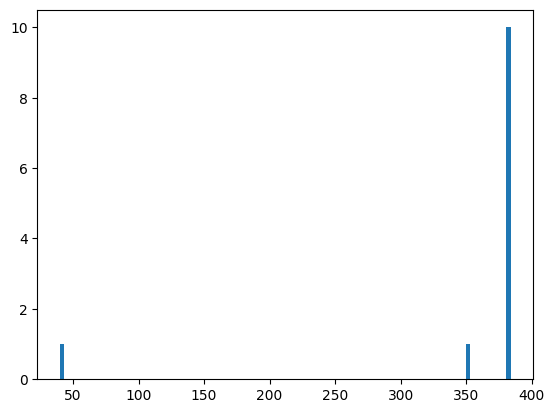

In [27]:
tracks_length = []
for track_id, track in tracks.items():
    if len(track) > 10:
        tracks_length.append(len(track))
plt.hist(tracks_length, bins=100)


In [28]:

import matplotlib as mpl

In [29]:
cmap = mpl.colormaps['tab20']
colors = [(np.array(c) * 255) for c in cmap.colors]


In [30]:
ds = VideoDataset(video_file)
data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)
out_name = "test-track-2.mp4"

output_params = {"-input_framerate": 30,
                "-pix_fmt": "yuv420p"}
writer = WriteGear(output=os.path.join(out_folder, out_name),
                **output_params) 

t0 = time.time()
first_frame = 0
max_im = None # 10000
for ind, f in enumerate(data_loader):
    if ind < first_frame:
        continue
    if max_im is not None:
        if ind >= max_im:
            break
    if ind % 1000 == 0:
        print(f"Frame number {ind} processed.")

    frame = f[0].numpy().copy() # Copy makes circle work for unclear reasons

    for track_id, track in tracks.items():
        if ind in track:
            box = track[ind]
            x = box[0] + int(box[2] / 2)
            y = box[1] + int(box[3] / 2)
            color = colors[track_id % len(colors)]
            cv2.circle(frame, [int(x), int(y)], 8, (int(color[0]), int(color[1]), int(color[2])), -1)
            cv2.putText(frame, str(track_id), (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    if frame is not None:
        writer.write(frame, rgb_mode=True)
    else:
        print("skipping.")

    if ind > 20000:
        break
ds.stop()   

writer.close()
total_time = time.time() - t0
print(total_time, f"fps: {ind / total_time}", f"{ind} frames processed.")

14:46:14 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Frame number 0 processed.
Empty frame. Ending stream.
FileVideoStream stopped.
13.730254650115967 fps: 27.894602813995526 383 frames processed.


In [31]:
type(color[0]), color[1], color[2]

(numpy.float64, 119.0, 194.0)

In [32]:
tracks.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

In [34]:
create_video = True
for video_file in video_name: #changing  to get rid of the plural (video_names)
    video_name = os.path.splitext(os.path.basename(video_file))[0]
    out_name = video_name # probably needs .mp4
    ds = VideoDataset(video_file)
    data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)

    if create_video:
        output_params = {"-input_framerate": 30,
                    "-pix_fmt": "yuv420p"}
        writer = WriteGear(output=os.path.join(out_folder, out_name),
                        **output_params) 


    all_boxes = []
    all_scores = []

    t0 = time.time()
    first_frame = 0
    max_im = None # 10000
    for ind, f in enumerate(data_loader):
        if ind < first_frame:
            continue
        if max_im is not None:
            if ind >= max_im:
                break
        if ind % 1000 == 0:
            print(f"Frame number {ind} processed.")
        res = predictor(f[0])
        boxes = res['boxes'].to('cpu').numpy().astype(np.uint32)
        scores = res['scores'].to('cpu').numpy()
        labels = res['labels'].to('cpu').numpy()

        image_name = f"{video_name}-frame-{ind}"

        all_boxes.append(boxes)
        all_scores.append(scores)

        if create_video:
            frame = f[0].numpy().copy() # Copy makes circle work for unclear reasons
            
            for box, score, label in zip(boxes, scores, labels):
                if score < .9:
                    continue
                x = np.mean([box[0], box[2]])
                y = np.mean([box[1], box[3]])
                if label == 1:
                    cv2.circle(frame, [int(x), int(y)], 4, (4,217,255), -1)
                else:
                    cv2.circle(frame, [int(x), int(y)], 8, (255, 0, 0), -1)
            if frame is not None:
                writer.write(frame[:720, :1280], rgb_mode=True)
            else:
                print("skipping.")
    ds.stop()   
    if create_video: 
        writer.close()
    total_time = time.time() - t0
    print(total_time, f"fps: {ind / total_time}", f"{ind} frames processed.")

    np.savez_compressed(os.path.join(out_folder, f"{video_name}-boxes.npz"), *all_boxes)
    np.savez_compressed(os.path.join(out_folder, f"{video_name}-scores.npz"), *all_scores)

14:56:06 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Empty frame. Ending stream.
FileVideoStream stopped.
0.000335693359375 fps: 1140922.1818181819 383 frames processed.


14:56:07 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Empty frame. Ending stream.
FileVideoStream stopped.
0.0001914501190185547 fps: 2000521.085927771 383 frames processed.


14:56:08 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


...

Empty frame. Ending stream.
FileVideoStream stopped.
0.00019788742065429688 fps: 1935443.8939759035 383 frames processed.


14:56:17 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Empty frame. Ending stream.
FileVideoStream stopped.
0.0001881122589111328 fps: 2036018.2915082383 383 frames processed.


14:56:18 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Empty frame. Ending stream.
FileVideoStream stopped.
0.0003228187561035156 fps: 1186424.248153619 383 frames processed.


In [35]:
output_params = {"-input_framerate": 30,
# }
                "-pix_fmt": "yuv420p"}
writer = WriteGear(output=os.path.join(out_folder, out_name),
                **output_params) 

for i in range(300):
    writer.write(np.ones((400, 400, 3)), rgb_mode=True)

writer.close()



14:56:39 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!
14:56:39 ::   WriteGear   ::  ERROR   :: BrokenPipeError caught, Wrong values passed to FFmpeg Pipe. Kindly Refer Docs!


ValueError: 

In [ ]:
np.savez_compressed(os.path.join(out_folder, f"{video_name}-allboxes.npz"), *all_boxes)
np.savez_compressed(os.path.join(out_folder, f"{video_name}-allscores.npz"), *all_scores)

In [ ]:
os.path.join(out_folder, f"{video_name}-allboxes.npz")

In [ ]:
boxes = []
z = np.load(os.path.join(out_folder, f"{video_name}-boxes.npz"))
for key in z:
    boxes.append(z[key])

scores = []
z = np.load(os.path.join(out_folder, f"{video_name}-scores.npz"))
for key in z:
    scores.append(z[key])


In [ ]:
thresh = .7
counts = []
for frame_boxes, frame_scores in zip(boxes, scores):
    mask = frame_scores > thresh
    count = np.sum(mask)
    counts.append(count)

In [ ]:
plt.plot(counts)

In [ ]:
scores[0] >.8